Stats for TB683 (Glory)

Speed: 2.944608

 	- Spacy Sup. Speed Augmenter: 0.480(+)
 	- Phantomstream: 0.450(+)
 	- Ultimate Trader Controlbot: 0.050(+)
 	- Merchant Fleet Master: 0.480

Docking Speed: 10.690

 	- Calypso Augmenter: 9.50(+)

Thrust: 6.070368

 	- Calypso Augmenter: 0.60(+)
 	- Spacy Sup. Speed Augmenter: 0.480(+)
 	- Dark Freighter: 2.0(+)
 	- Merchant Fleet Master: 0.480

Turning: 1.993264

 	- Calypso Augmenter: 0.340(+)
 	- Merchant Fleet Master: 0.480

Weight: 0.320122

 	- Calypso Augmenter: -0.461538(+)
 	- Industrial freighter weight reduction: -0.40

Capacity: 5.412832

 	- Calypso Augmenter: 1.080(+)
 	- Spacy Sup. Speed Augmenter: 0.240(+)
 	- Ultimate Trader Controlbot: 0.040(+)
 	- Hydra Eyes*: 0.0310
 	- Merchant Fleet Master: 1.20

In [48]:
import itertools

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
((1 + 1.080 * 1.02 + 0.240 + 0.040)) * 1.0310 * 2.2

5.4019451200000015

In [3]:
(1 + 0.48 * 1.02 + 0.45 + 0.05) * 1.48

2.944608

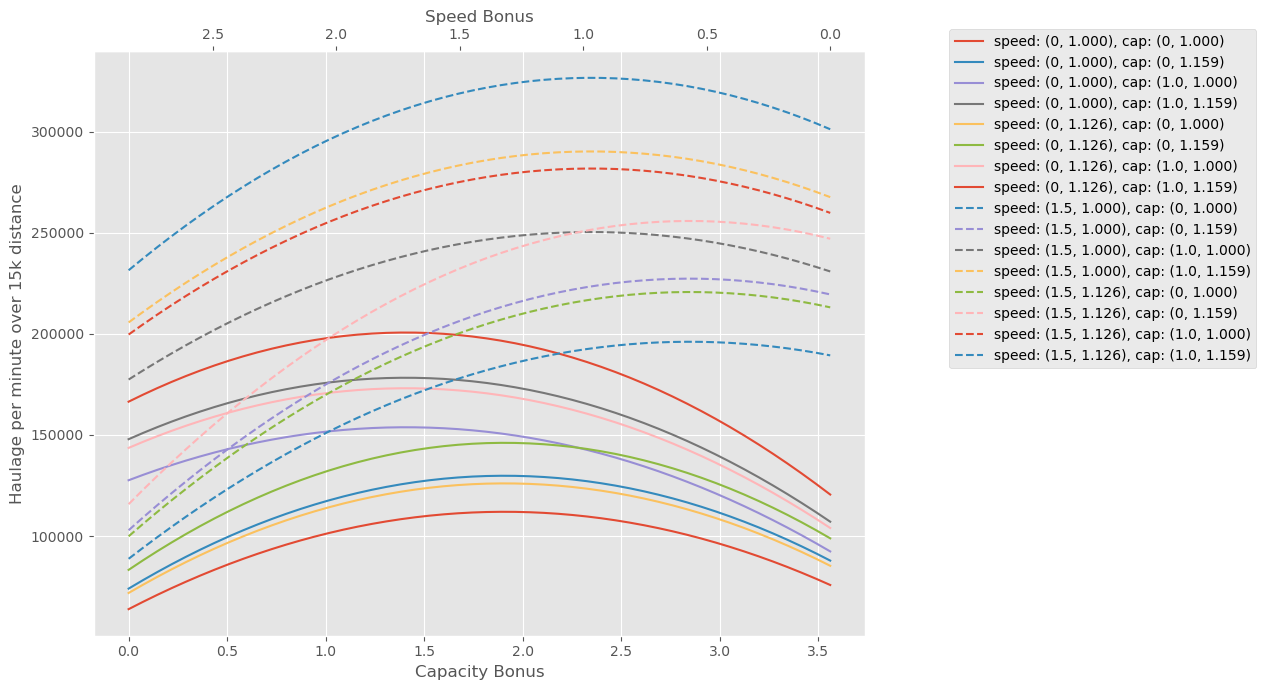

In [130]:
# aug_speed_bonus = 0.0
# aug_capacity_bonus = 0.0

f, ax = plt.subplots(figsize=(13, 7))

aug_speed_bonus = np.linspace(0.0, 2.84, 50)[::-1]
aug_capacity_bonus = np.linspace(0.0, 1.78*2, 50)

base_hull = 20360
base_speed = 51

for add_other_sources_speed in [0, 1.5]:
    for mult_other_sources_speed in [1.0, 1.03 ** 4]:
        for add_other_sources_cap in [0, 1.0]:
            for mult_other_sources_cap in [1.0, 1.03**5]:
                # add_other_sources_speed = 0.0
                # mult_other_sources_speed = 1.0

                # add_other_sources_cap = 0.0
                # mult_other_sources_cap = 1.0

                mfm = 30

                speed_mult = (1 + aug_speed_bonus + add_other_sources_speed) * mult_other_sources_speed * (1 + mfm * 0.02)
                cap_mult = (1 + aug_capacity_bonus + add_other_sources_cap) * mult_other_sources_cap * (1 + mfm * 0.05)

                final_speed = base_speed * speed_mult
                final_capacity = base_hull * cap_mult

                distance = 15000  # arbitrary

                # assuming speed is unit/s
                duration = distance / final_speed
                throughput_pmin = 60 / duration * final_capacity

                ls = "-" if add_other_sources_speed < 1 else "--"

                ax.plot(aug_capacity_bonus, throughput_pmin, ls=ls, label=f"speed: ({add_other_sources_speed}, {mult_other_sources_speed:.3f}), cap: ({add_other_sources_cap}, {mult_other_sources_cap:.3f})")


ax.set_xlabel("Capacity Bonus")
ax.set_ylabel("Haulage per minute over 15k distance")
ax.legend(bbox_to_anchor=(1.1, 1.05))

fn1 = lambda x: x / (aug_capacity_bonus[-1] - aug_capacity_bonus[0]) * (aug_speed_bonus[-1] - aug_speed_bonus[0]) + aug_speed_bonus[0]
fn2 = lambda x: x / (aug_speed_bonus[-1] - aug_speed_bonus[0]) * (aug_capacity_bonus[-1] - aug_capacity_bonus[0]) + aug_capacity_bonus[0]

axx = ax.secondary_xaxis(location='top', functions=(fn1, fn2))
axx.set_xlabel("Speed Bonus")

f.tight_layout()

# Common aug combinations

In [91]:
ada_sardine = {"speed": 0.0, "capacity": 1.78, "name": "Ada Sardine"}
ada_racer = {"speed": 1.42, "capacity": 0.0, "name": "Ada Racer"}
sup_smuggling = {"speed": 0.78, "capacity": 0.55, "name": "Sup. Smuggling"}
# speed_sup_cap = {"speed": 0.24, "capacity": 1.0, "name": "Speedy Sup. Cap"}
# spacey_sup_speed = {"speed": 0.48, "capacity": 0.24, "name": "Spacey Sup. Speed"}

aug_combs = itertools.combinations_with_replacement([ada_sardine, ada_racer, sup_smuggling], r=2)

aug_bonuses = []
for comb in aug_combs:
    aug_bonuses.append(
        {
            "speed": comb[0]['speed'] + comb[1]['speed'],
            "capacity": comb[0]['capacity'] + comb[1]['capacity'],
            "augs": f"{comb[0]['name']}, {comb[1]['name']}"
        }
    )

In [92]:
df = pl.DataFrame(aug_bonuses)

df = df.with_columns(
    pl.lit(0.0).alias("speed+"),
    pl.lit(1.0).alias("speed*"),
    pl.lit(0.0).alias("capacity+"),
    pl.lit(1.0).alias("capacity*"),
    pl.lit(30).alias("mfm")
).with_columns(
    ((pl.lit(1) + pl.col("speed") + pl.col("speed+")) * pl.col("speed*") * (1 + pl.col("mfm") * 0.02)).alias("speed_mult"),
    ((pl.lit(1) + pl.col("capacity") + pl.col("capacity+")) * pl.col("capacity*") * (1 + pl.col("mfm") * 0.02)).alias("capacity_mult")
)

In [93]:
df

speed,capacity,augs,speed+,speed*,capacity+,capacity*,mfm,speed_mult,capacity_mult
f64,f64,str,f64,f64,f64,f64,i32,f64,f64
0.0,3.56,"""Ada Sardine, Ada Sardine""",0.0,1.0,0.0,1.0,30,1.6,7.296
1.42,1.78,"""Ada Sardine, Ada Racer""",0.0,1.0,0.0,1.0,30,3.872,4.448
0.78,2.33,"""Ada Sardine, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,2.848,5.328
2.84,0.0,"""Ada Racer, Ada Racer""",0.0,1.0,0.0,1.0,30,6.144,1.6
2.2,0.55,"""Ada Racer, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,5.12,2.48
1.56,1.1,"""Sup. Smuggling, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,4.096,3.36


In [117]:
ship_data = [
    {
        "ship": "DF",
        "base_speed": 51,
        "base_hull": 20360,
    },
    {
        "ship": "DF+",
        "base_speed": 53,
        "base_hull": 21378
    },
    {
        "ship": "Zaphragi Arc",
        "base_speed": 10,
        "base_hull": 151764
    }
]
ships = pl.DataFrame(ship_data)

In [118]:
ships

ship,base_speed,base_hull
str,i64,i64
"""DF""",51,20360
"""DF+""",53,21378
"""Zaphragi Arc""",10,151764


In [119]:
data = ships.join(df, how='cross')

data = data.with_columns(
    final_speed=pl.col("base_speed") * pl.col("speed_mult"),
    final_hull=pl.col("base_hull") * pl.col("capacity_mult")
).with_columns(
    duration=15000 / pl.col("final_speed"),
).with_columns(
    throughput_pmin=(60/pl.col("duration")) * pl.col("final_hull")
)

In [120]:
data

ship,base_speed,base_hull,speed,capacity,augs,speed+,speed*,capacity+,capacity*,mfm,speed_mult,capacity_mult,final_speed,final_hull,duration,throughput_pmin
str,i64,i64,f64,f64,str,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64
"""DF""",51,20360,0.0,3.56,"""Ada Sardine, Ada Sardine""",0.0,1.0,0.0,1.0,30,1.6,7.296,81.6,148546.56,183.823529,48485.597184
"""DF""",51,20360,1.42,1.78,"""Ada Sardine, Ada Racer""",0.0,1.0,0.0,1.0,30,3.872,4.448,197.472,90561.28,75.960136,71533.268337
"""DF""",51,20360,0.78,2.33,"""Ada Sardine, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,2.848,5.328,145.248,108478.08,103.271646,63024.896655
"""DF""",51,20360,2.84,0.0,"""Ada Racer, Ada Racer""",0.0,1.0,0.0,1.0,30,6.144,1.6,313.344,32576.0,47.870711,40829.976576
"""DF""",51,20360,2.2,0.55,"""Ada Racer, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,5.12,2.48,261.12,50492.8,57.444853,52738.719744
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zaphragi Arc""",10,151764,1.42,1.78,"""Ada Sardine, Ada Racer""",0.0,1.0,0.0,1.0,30,3.872,4.448,38.72,675046.272,387.396694,104551.166607
"""Zaphragi Arc""",10,151764,0.78,2.33,"""Ada Sardine, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,2.848,5.328,28.48,808598.592,526.685393,92115.551601
"""Zaphragi Arc""",10,151764,2.84,0.0,"""Ada Racer, Ada Racer""",0.0,1.0,0.0,1.0,30,6.144,1.6,61.44,242822.4,244.140625,59676.033024


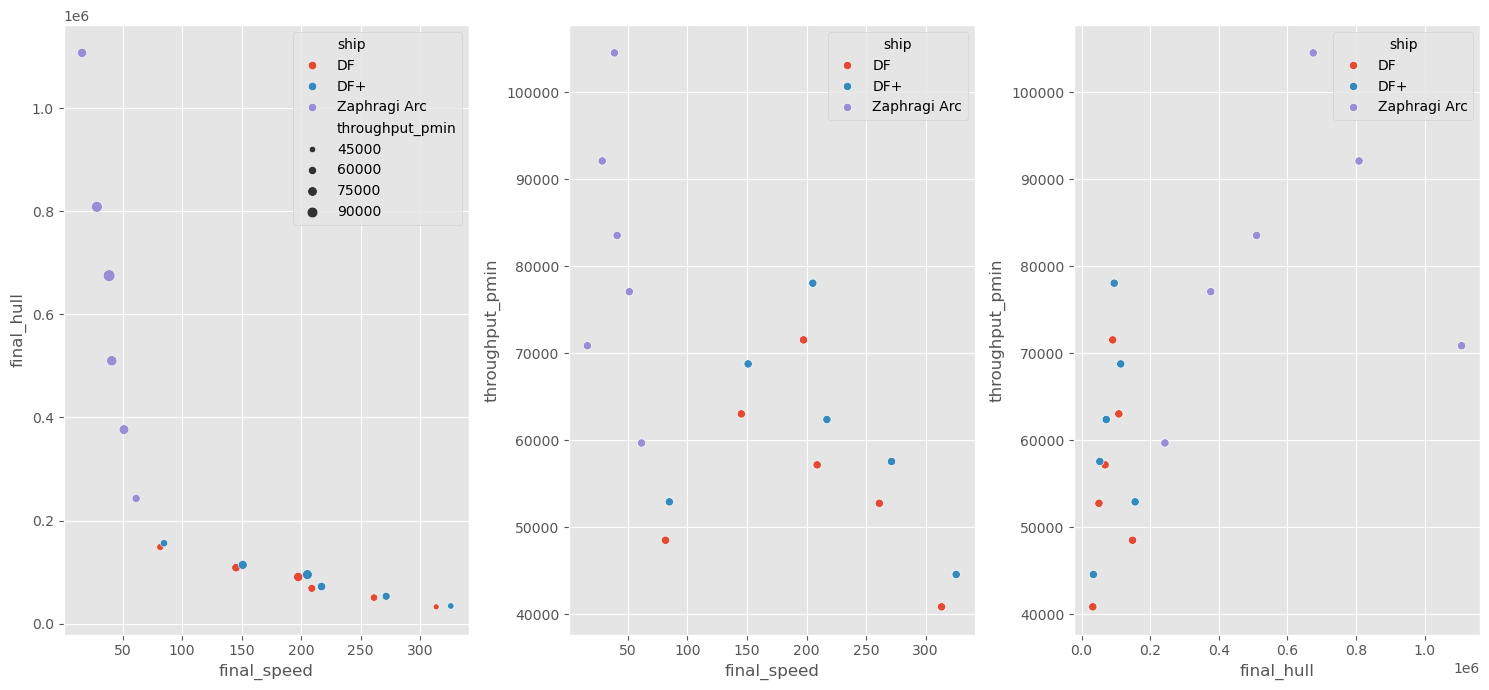

In [121]:
f, (ax, ax1, ax2) = plt.subplots(ncols=3, figsize=(15, 7))
sns.scatterplot(data=data, x="final_speed", y="final_hull", hue='ship', size="throughput_pmin", ax=ax)
sns.scatterplot(data=data, x="final_speed", y="throughput_pmin", hue="ship", ax=ax1)
sns.scatterplot(data=data, x="final_hull", y="throughput_pmin", hue="ship", ax=ax2)

f.tight_layout()

In [122]:
with pl.Config(tbl_rows=30):
    display(data.sort("throughput_pmin", descending=True))

ship,base_speed,base_hull,speed,capacity,augs,speed+,speed*,capacity+,capacity*,mfm,speed_mult,capacity_mult,final_speed,final_hull,duration,throughput_pmin
str,i64,i64,f64,f64,str,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64
"""Zaphragi Arc""",10,151764,1.42,1.78,"""Ada Sardine, Ada Racer""",0.0,1.0,0.0,1.0,30,3.872,4.448,38.72,675046.272,387.396694,104551.166607
"""Zaphragi Arc""",10,151764,0.78,2.33,"""Ada Sardine, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,2.848,5.328,28.48,808598.592,526.685393,92115.551601
"""Zaphragi Arc""",10,151764,1.56,1.1,"""Sup. Smuggling, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,4.096,3.36,40.96,509927.04,366.210938,83546.446234
"""DF+""",53,21378,1.42,1.78,"""Ada Sardine, Ada Racer""",0.0,1.0,0.0,1.0,30,3.872,4.448,205.216,95089.344,73.093716,78055.419273
"""Zaphragi Arc""",10,151764,2.2,0.55,"""Ada Racer, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,5.12,2.48,51.2,376374.72,292.96875,77081.542656
"""DF""",51,20360,1.42,1.78,"""Ada Sardine, Ada Racer""",0.0,1.0,0.0,1.0,30,3.872,4.448,197.472,90561.28,75.960136,71533.268337
"""Zaphragi Arc""",10,151764,0.0,3.56,"""Ada Sardine, Ada Sardine""",0.0,1.0,0.0,1.0,30,1.6,7.296,16.0,1.1073e6,937.5,70865.289216
"""DF+""",53,21378,0.78,2.33,"""Ada Sardine, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,2.848,5.328,150.944,113901.984,99.374603,68771.284292
"""DF""",51,20360,0.78,2.33,"""Ada Sardine, Sup. Smuggling""",0.0,1.0,0.0,1.0,30,2.848,5.328,145.248,108478.08,103.271646,63024.896655
